# BDD100K Dataset Exploration

In [3]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from collections import Counter


ROOT = '/home/hice1/wstevens35/scratch/bdd100k/bdd100k/'
LABEL_TRAIN = ROOT + 'labels/det_v2_train_release.json'
LABEL_VAL = ROOT + '/labels/det_v2_val_release.json'
IMG_TRAIN = os.path.join(ROOT, 'images/100k/train/')
IMG_VAL = os.path.join(ROOT, 'images/100k/val/')


In [4]:
with open(LABEL_TRAIN) as f:
    train_data = json.load(f)
with open(LABEL_VAL) as f:
    val_data = json.load(f)

df_train = pd.DataFrame(train_data)
df_val = pd.DataFrame(val_data)

# Drop images with no labels
df_train = df_train.dropna(subset=['labels']).reset_index(drop=True)
df_val = df_val.dropna(subset=['labels']).reset_index(drop=True)

print(f'Train images with labels: {len(df_train)}')
print(f'Val images with labels: {len(df_val)}')
print(f'\nSample entry:')
print(df_train.iloc[0])

Train images with labels: 69853
Val images with labels: 10000

Sample entry:
videoName                                     0000f77c-6257be58
name                                      0000f77c-6257be58.jpg
index                                                         0
timestamp                                                 10000
labels        [{'category': 'traffic light', 'poly2d': None,...
attributes    {'weather': 'clear', 'timeofday': 'daytime', '...
Name: 0, dtype: object


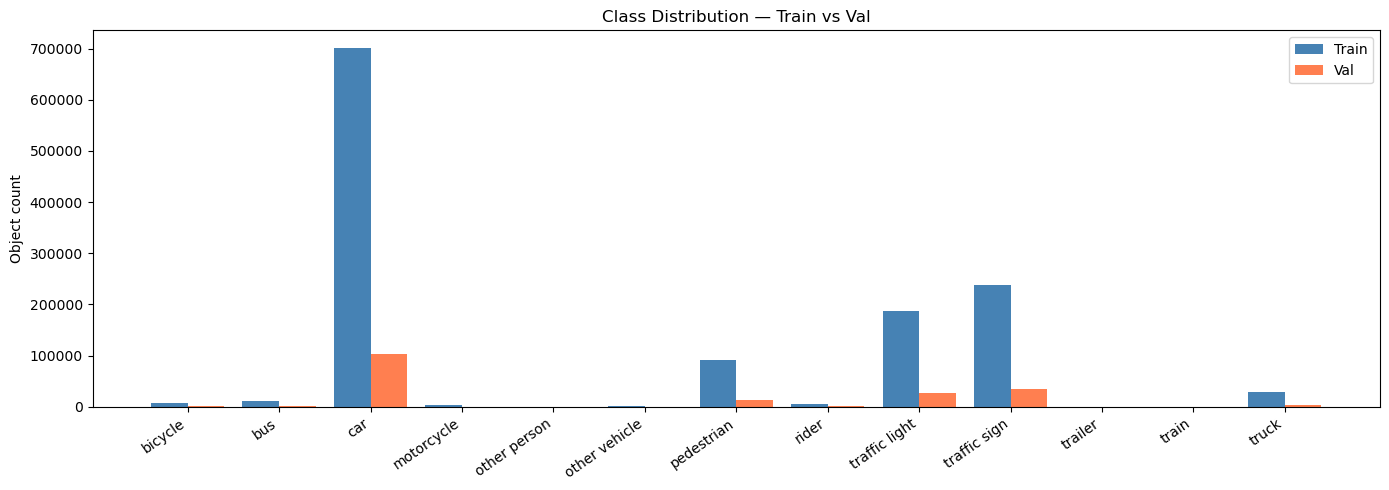


Train counts:
  car                  700,703
  traffic sign         238,270
  traffic light        187,871
  pedestrian            92,159
  truck                 27,892
  bus                   11,977
  bicycle                7,124
  rider                  4,560
  motorcycle             3,023
  other vehicle            804
  other person             210
  train                    128
  trailer                   71


In [5]:
# Class distribution
def count_classes(df):
    counts = Counter()
    for labels in df['labels']:
        for obj in labels:
            counts[obj['category']] += 1
    return counts

train_counts = count_classes(df_train)
val_counts = count_classes(df_val)

classes = sorted(train_counts.keys())
train_vals = [train_counts[c] for c in classes]
val_vals = [val_counts[c] for c in classes]

x = np.arange(len(classes))
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 0.2, train_vals, 0.4, label='Train', color='steelblue')
ax.bar(x + 0.2, val_vals, 0.4, label='Val', color='coral')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=35, ha='right')
ax.set_ylabel('Object count')
ax.set_title('Class Distribution — Train vs Val')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTrain counts:')
for c, n in sorted(train_counts.items(), key=lambda x: -x[1]):
    print(f'  {c:<20} {n:>7,}')

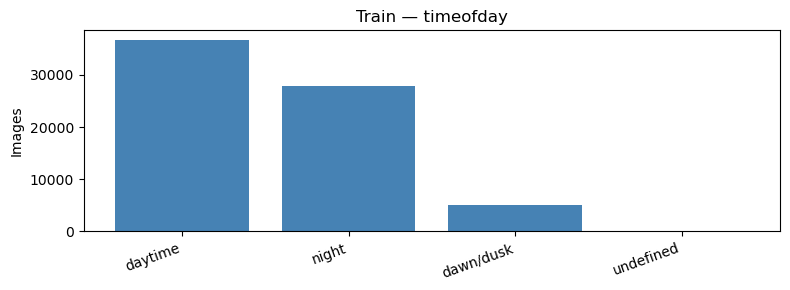

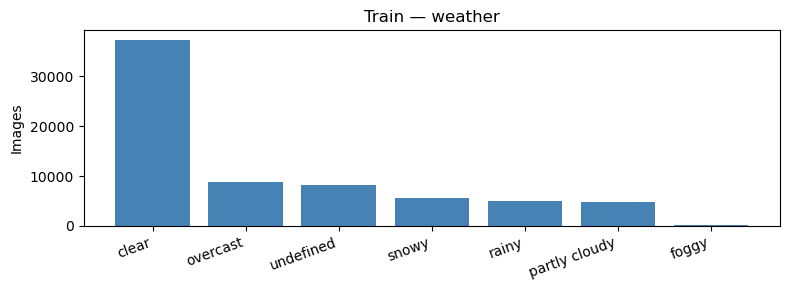

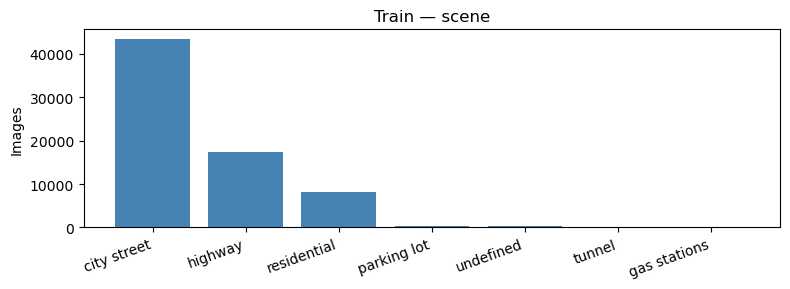

In [6]:
# Attribute breakdown: timeofday, weather, scene
def count_attribute(df, key):
    return Counter(row.get(key) for row in df['attributes'] if isinstance(row, dict))

for attr in ['timeofday', 'weather', 'scene']:
    counts = count_attribute(df_train, attr)
    labels, values = zip(*sorted(counts.items(), key=lambda x: -x[1]))
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.bar(labels, values, color='steelblue')
    ax.set_title(f'Train — {attr}')
    ax.set_ylabel('Images')
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

In [7]:
# Day vs Night split sizes
for tod in ['daytime', 'night', 'dawn/dusk', 'undefined']:
    mask = df_train['attributes'].apply(
        lambda a: a.get('timeofday') == tod if isinstance(a, dict) else False
    )
    print(f'{tod:<15} {mask.sum():>6,} train images')

daytime         36,728 train images
night           27,961 train images
dawn/dusk        5,027 train images
undefined          137 train images


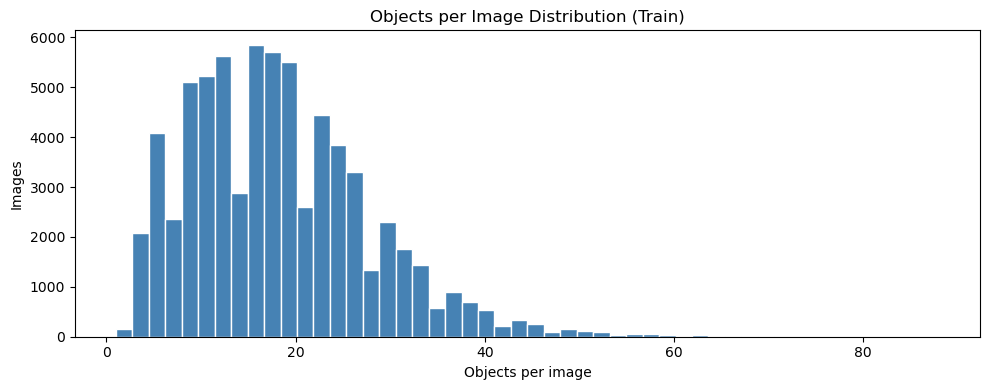

Mean objects per image: 18.25
Max objects per image: 88
Min objects per image: 1


In [8]:
# Objects per image distribution
obj_counts = df_train['labels'].apply(len)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(obj_counts, bins=50, color='steelblue', edgecolor='white')
ax.set_xlabel('Objects per image')
ax.set_ylabel('Images')
ax.set_title('Objects per Image Distribution (Train)')
plt.tight_layout()
plt.show()

print(f'Mean objects per image: {obj_counts.mean():.2f}')
print(f'Max objects per image: {obj_counts.max()}')
print(f'Min objects per image: {obj_counts.min()}')

Small objects (area < 0.1%): 683,453 (53.6%)
Medium objects (0.1% – 1%): 428,970 (33.7%)
Large objects (area > 1%): 162,369 (12.7%)


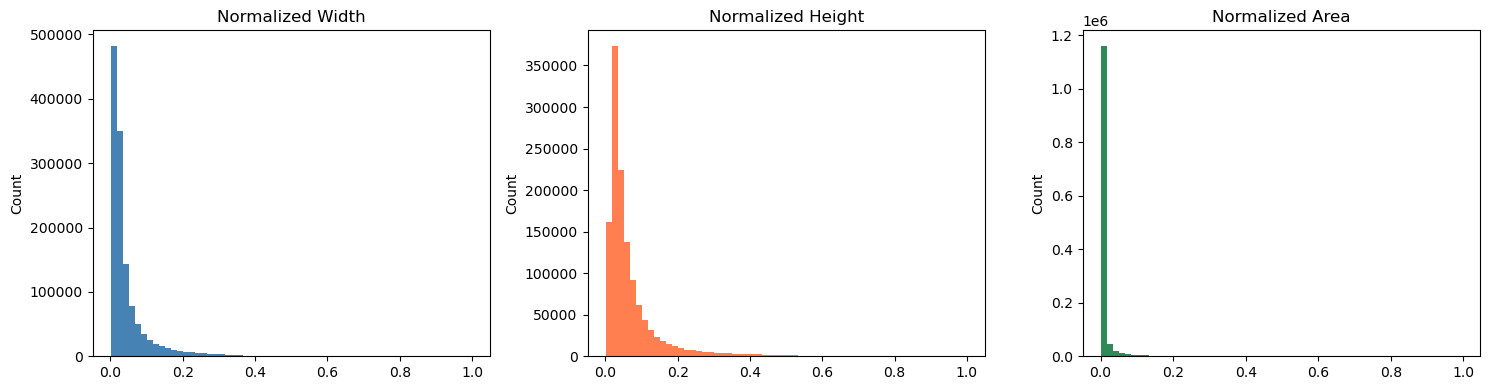

In [9]:
# Bounding box size distribution
widths, heights, areas = [], [], []
IMG_W, IMG_H = 1280, 720

for labels in df_train['labels']:
    for obj in labels:
        b = obj.get('box2d')
        if b is None:
            continue
        w = (b['x2'] - b['x1']) / IMG_W
        h = (b['y2'] - b['y1']) / IMG_H
        widths.append(w)
        heights.append(h)
        areas.append(w * h)

# Small / medium / large split
areas_np = np.array(areas)
small  = (areas_np < 0.032**2).sum()
medium = ((areas_np >= 0.032**2) & (areas_np < 0.1**2)).sum()
large  = (areas_np >= 0.1**2).sum()
total  = len(areas_np)

print(f'Small objects (area < 0.1%): {small:>7,} ({100*small/total:.1f}%)')
print(f'Medium objects (0.1% – 1%): {medium:>7,} ({100*medium/total:.1f}%)')
print(f'Large objects (area > 1%): {large:>7,} ({100*large/total:.1f}%)')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(widths, bins=60, color='steelblue'); axes[0].set_title('Normalized Width')
axes[1].hist(heights, bins=60, color='coral'); axes[1].set_title('Normalized Height')
axes[2].hist(areas, bins=60, color='seagreen'); axes[2].set_title('Normalized Area')
for ax in axes:
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

In [10]:
# Occlusion / truncation stats
occluded, truncated, total = 0, 0, 0
for labels in df_train['labels']:
    for obj in labels:
        attrs = obj.get('attributes', {})
        if attrs.get('occluded'):  occluded  += 1
        if attrs.get('truncated'): truncated += 1
        total += 1

print(f'Total objects: {total:,}')
print(f'Occluded: {occluded:,} ({100*occluded/total:.1f}%)')
print(f'Truncated: {truncated:,} ({100*truncated/total:.1f}%)')

Total objects: 1,274,792
Occluded: 607,210 (47.6%)
Truncated: 86,579 (6.8%)


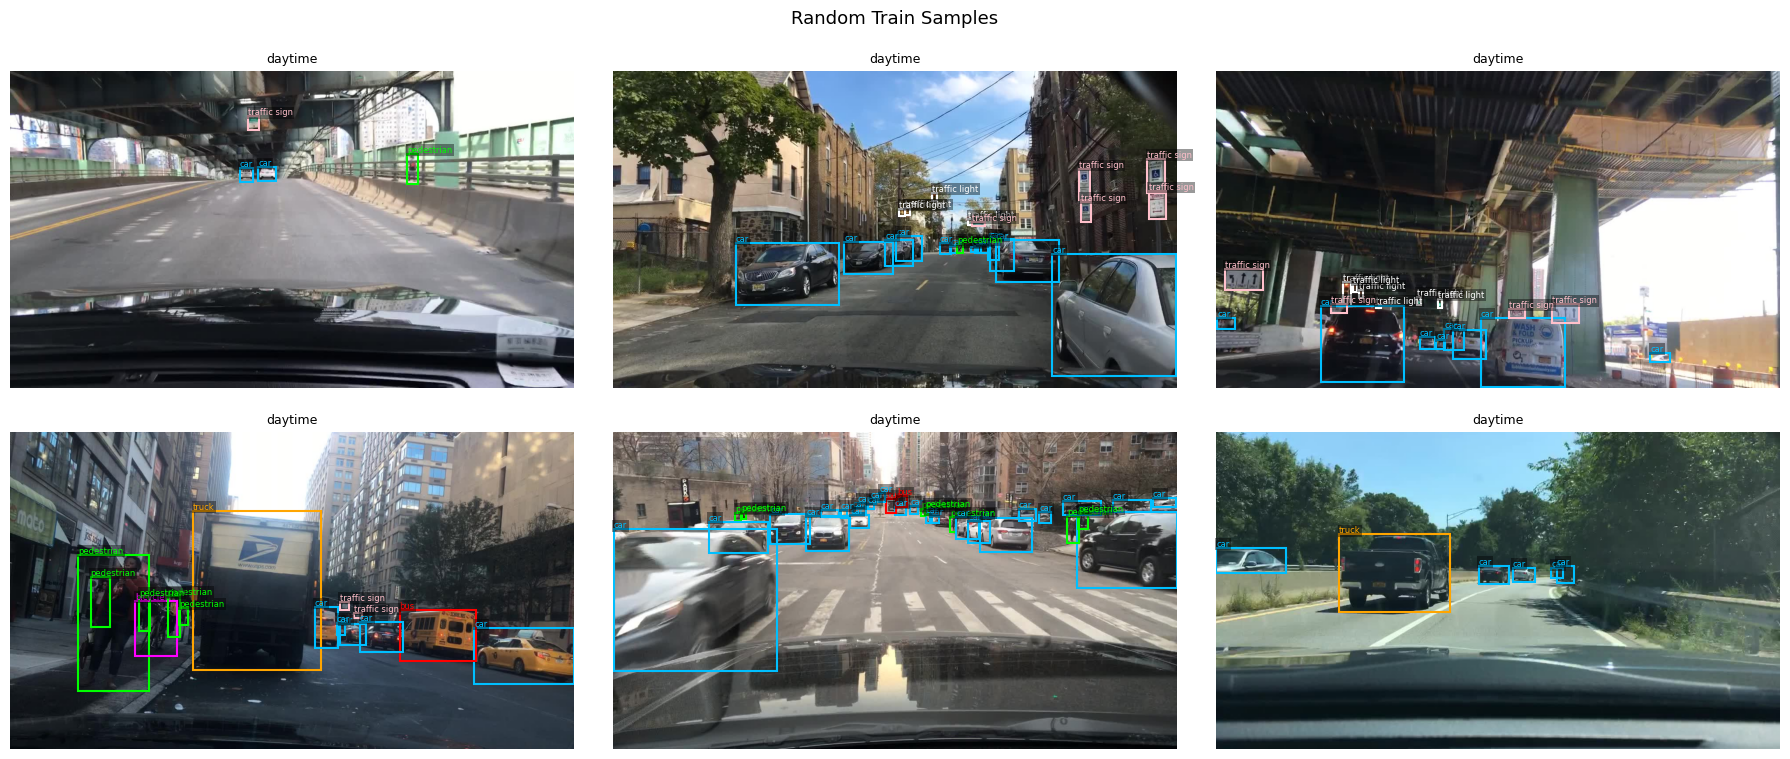

In [12]:
# Visualize
COLORS = {
    'car': 'deepskyblue',
    'truck': 'orange',
    'bus': 'red',
    'pedestrian': 'lime',
    'rider': 'yellow',
    'bicycle': 'magenta',
    'motorcycle': 'cyan',
    'traffic light': 'white',
    'traffic sign': 'pink',
    'train': 'brown',
    'other vehicle': 'gray',
    'trailer': 'olive',
    'other person': 'teal',
}

def show_images(df, img_dir, n=6, title=''):
    samples = df.sample(n).reset_index(drop=True)
    fig, axes = plt.subplots(2, n//2, figsize=(18, 8))
    axes = axes.flatten()
    for i, (_, row) in enumerate(samples.iterrows()):
        img = Image.open(os.path.join(img_dir, row['name']))
        ax = axes[i]
        ax.imshow(img)
        for obj in row['labels']:
            b = obj.get('box2d')
            cat = obj.get('category', 'unknown')
            if b is None:
                continue
            x1, y1 = b['x1'], b['y1']
            w = b['x2'] - b['x1']
            h = b['y2'] - b['y1']
            color = COLORS.get(cat, 'white')
            rect = patches.Rectangle((x1, y1), w, h,
                                       linewidth=1.5, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 3, cat, color=color, fontsize=6,
                    bbox=dict(facecolor='black', alpha=0.4, pad=1, edgecolor='none'))
        attrs = row.get('attributes', {})
        tod = attrs.get('timeofday', '') if isinstance(attrs, dict) else ''
        ax.set_title(f"{tod}", fontsize=9)
        ax.axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_images(df_train, IMG_TRAIN, n=6, title='Random Train Samples')

In [13]:
# Test the dataloader
import sys
sys.path.append('/home/hice1/wstevens35/Desktop/CCV/YOLOv4_BDD100k')

from torch.utils.data import DataLoader
from bdd100k import BDD100k

dataset = BDD100k(
    root=ROOT,
    train=True,
)

loader = DataLoader(dataset, batch_size=4, shuffle=True, num_workers=2)

imgs, labels = next(iter(loader))
print(f'Image batch shape: {imgs.shape}')          # (4, 3, H, W)
print(f'Label scales: {len(labels)}')
for i, l in enumerate(labels):
    print(f' - Scale {i} label shape: {l.shape}')

Image batch shape: torch.Size([4, 3, 720, 1280])
Label scales: 3
 - Scale 0 label shape: torch.Size([4, 3, 90, 160, 18])
 - Scale 1 label shape: torch.Size([4, 3, 45, 80, 18])
 - Scale 2 label shape: torch.Size([4, 3, 23, 40, 18])
